In [1]:
# =========================
# 1) Imports
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

In [2]:
# =========================
# 2) Load data
# =========================
DATA_PATH = "/home/fyp_ids_e20/processed_dataset/balanced_network_data.csv"
df = pd.read_csv(DATA_PATH)

print("Loaded shape:", df.shape)
print(df["Label"].value_counts().head(20))

Loaded shape: (6870587, 23)
Label
Benign                      4122352
DDOS attack-HOIC             686012
DDoS attacks-LOIC-HTTP       576191
DoS attacks-Hulk             461912
Bot                          286191
FTP-BruteForce               193360
SSH-Bruteforce               187589
Infilteration                161934
DoS attacks-SlowHTTPTest     139890
DoS attacks-GoldenEye         41508
DoS attacks-Slowloris         10990
DDOS attack-LOIC-UDP           1730
Brute Force -Web                611
Brute Force -XSS                230
SQL Injection                    87
Name: count, dtype: int64


In [3]:
# =========================
# 3) Feature list (yours)
# =========================
network_features = [
    "Dst Port",
    "Protocol",
    "Flow Duration",
    "Flow IAT Mean",
    "Flow IAT Max",
    "Flow IAT Min",
    "Fwd IAT Max",
    "Fwd IAT Min",
    "Fwd IAT Tot",
    "Flow Pkts/s",
    "Fwd Pkts/s",
    "Bwd Pkts/s",
    "Tot Fwd Pkts",
    "Subflow Fwd Pkts",
    "Fwd Header Len",
    "Bwd Header Len",
    "Init Fwd Win Byts",
    "Init Bwd Win Byts",
    "PSH Flag Cnt",
    "RST Flag Cnt",
    "ACK Flag Cnt",
    "ECE Flag Cnt"
]

# keep only features that exist (avoids KeyError if name mismatch)
missing = [c for c in network_features if c not in df.columns]
if missing:
    print("WARNING: These features are missing in your CSV and will be skipped:")
    print(missing)

network_features = [c for c in network_features if c in df.columns]
print("Using", len(network_features), "features.")

Using 22 features.


In [4]:
# =========================
# 4) Clean data
# =========================
# Replace inf/-inf with NaN
df = df.replace([np.inf, -np.inf], np.nan)

# Keep only rows with Label
df = df.dropna(subset=["Label"]).copy()

# Build X/y using only selected features
y = df["Label"].astype(str).copy()
X = df[network_features].copy()

# Force numeric conversion (handles cases where numbers were read as object)
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# Drop rows with NaN in selected features
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

print("After cleaning, X shape:", X.shape, "y shape:", y.shape)
print("Label counts (top 15):")
print(y.value_counts().head(15))

After cleaning, X shape: (6838750, 22) y shape: (6838750,)
Label counts (top 15):
Label
Benign                      4091816
DDOS attack-HOIC             686012
DDoS attacks-LOIC-HTTP       576191
DoS attacks-Hulk             461912
Bot                          286191
FTP-BruteForce               193354
SSH-Bruteforce               187589
Infilteration                160639
DoS attacks-SlowHTTPTest     139890
DoS attacks-GoldenEye         41508
DoS attacks-Slowloris         10990
DDOS attack-LOIC-UDP           1730
Brute Force -Web                611
Brute Force -XSS                230
SQL Injection                    87
Name: count, dtype: int64


In [5]:
# =========================
# 5) Split into benign vs attacks
# =========================
X_benign = X[y == "Benign"]
X_attack = X[y != "Benign"]
y_attack = y[y != "Benign"]

print("\nBenign samples:", len(X_benign))
print("Attack samples:", len(X_attack))
print("Attack label distribution (top 15):")
print(y_attack.value_counts().head(15))


Benign samples: 4091816
Attack samples: 2746934
Attack label distribution (top 15):
Label
DDOS attack-HOIC            686012
DDoS attacks-LOIC-HTTP      576191
DoS attacks-Hulk            461912
Bot                         286191
FTP-BruteForce              193354
SSH-Bruteforce              187589
Infilteration               160639
DoS attacks-SlowHTTPTest    139890
DoS attacks-GoldenEye        41508
DoS attacks-Slowloris        10990
DDOS attack-LOIC-UDP          1730
Brute Force -Web               611
Brute Force -XSS               230
SQL Injection                   87
Name: count, dtype: int64


In [6]:
# =========================
# 6) Train/Val split on Benign only (NO leakage)
# =========================
X_train_raw, X_val_raw = train_test_split(
    X_benign,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [7]:
# =========================
# 7) Scaling (fit ONLY on benign train)
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_attack_scaled = scaler.transform(X_attack)

print("\nScaled shapes:")
print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_attack_scaled:", X_attack_scaled.shape)


Scaled shapes:
X_train: (3273452, 22) X_val: (818364, 22) X_attack_scaled: (2746934, 22)


In [8]:
# =========================
# 8) Train Isolation Forest (fit on benign train only)
# =========================
iso = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)
iso.fit(X_train)
print("\nIsolation Forest trained.")


Isolation Forest trained.


In [9]:
# Get anomaly scores
val_scores = -iso.decision_function(X_val)
attack_scores = -iso.decision_function(X_attack_scaled)

# Try different thresholds
for p in [90, 92, 95, 97, 99]:
    threshold = np.percentile(val_scores, p)

    y_val_pred = (val_scores > threshold).astype(int)
    y_attack_pred = (attack_scores > threshold).astype(int)

    y_true = np.concatenate([
        np.zeros(len(y_val_pred)),
        np.ones(len(y_attack_pred))
    ])

    y_pred = np.concatenate([y_val_pred, y_attack_pred])

    print(f"\nThreshold percentile: {p}")
    print(confusion_matrix(y_true, y_pred, labels=[0, 1]))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["Benign", "Attack"]))


Threshold percentile: 90
[[ 736531   81833]
 [2300028  446906]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.24      0.90      0.38    818364
      Attack       0.85      0.16      0.27   2746934

    accuracy                           0.33   3565298
   macro avg       0.54      0.53      0.33   3565298
weighted avg       0.71      0.33      0.30   3565298


Threshold percentile: 92
[[ 752896   65468]
 [2529730  217204]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.23      0.92      0.37    818364
      Attack       0.77      0.08      0.14   2746934

    accuracy                           0.27   3565298
   macro avg       0.50      0.50      0.26   3565298
weighted avg       0.64      0.27      0.19   3565298


Threshold percentile: 95
[[ 777445   40919]
 [2661568   85366]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.23 

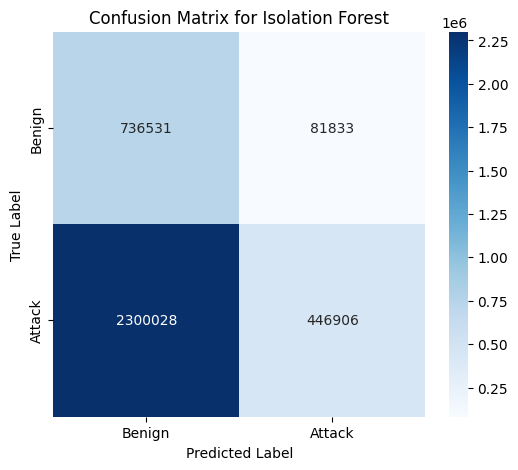

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = np.array([
    [736531, 81833],
    [2300028, 446906]
])

labels = ["Benign", "Attack"]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Isolation Forest")

plt.show()

In [10]:
# =========================
# 10) ROC-AUC using anomaly scores (better signal)
# =========================
# decision_function: higher means more normal
score_val = iso.decision_function(X_val)
score_attack = iso.decision_function(X_attack_scaled)

# invert -> higher means more anomalous
anomaly_score_val = -score_val
anomaly_score_attack = -score_attack

y_scores = np.concatenate([anomaly_score_val, anomaly_score_attack])
auc = roc_auc_score(y_true, y_scores)
print("ROC-AUC:", auc)

ROC-AUC: 0.6719642622315428


In [11]:
# =========================
# 11) Per-attack detection rate
# =========================
attack_labels = y_attack.value_counts().index.tolist()

rows = []
for lab in attack_labels:
    X_lab = X[y == lab]
    X_lab_scaled = scaler.transform(X_lab)
    pred_lab = iso.predict(X_lab_scaled)
    y_lab_pred = (pred_lab == -1).astype(int)

    detection_rate = y_lab_pred.mean()  # fraction flagged as anomaly
    rows.append((lab, len(X_lab), detection_rate))

report_df = pd.DataFrame(rows, columns=["Attack Label", "Samples", "Detection Rate (flagged anomaly)"])
report_df = report_df.sort_values("Detection Rate (flagged anomaly)", ascending=False)

print("\nPer-attack detection rate (top 20):")
print(report_df.head(20))

report_df


Per-attack detection rate (top 20):
                Attack Label  Samples  Detection Rate (flagged anomaly)
10      DDOS attack-LOIC-UDP     1730                          1.000000
4             FTP-BruteForce   193354                          0.850078
7   DoS attacks-SlowHTTPTest   139890                          0.787933
9      DoS attacks-Slowloris    10990                          0.723112
12          Brute Force -XSS      230                          0.491304
11          Brute Force -Web      611                          0.459902
1     DDoS attacks-LOIC-HTTP   576191                          0.436190
0           DDOS attack-HOIC   686012                          0.238698
5             SSH-Bruteforce   187589                          0.236405
6              Infilteration   160639                          0.191473
8      DoS attacks-GoldenEye    41508                          0.184013
13             SQL Injection       87                          0.022989
2           DoS attacks-Hul

,Attack Label,Samples,Detection Rate (flagged anomaly)
10,DDOS attack-LOIC-UDP,1730,1.000000
4,FTP-BruteForce,193354,0.850078
7,DoS attacks-SlowHTTPTest,139890,0.787933
9,DoS attacks-Slowloris,10990,0.723112
12,Brute Force -XSS,230,0.491304
11,Brute Force -Web,611,0.459902
1,DDoS attacks-LOIC-HTTP,576191,0.436190
0,DDOS attack-HOIC,686012,0.238698
5,SSH-Bruteforce,187589,0.236405
6,Infilteration,160639,0.191473
